# 🔬 Phase 2: Multi-Omics Feature Extraction, Regulatory Signatures & Integrated Feature Store
## Genomically Stable (GS) vs. Chromosomal Instability (CIN) Gastric Cancer

---

### 📌 Overview & Scientific Motivation
Gastric cancer molecular subtypes display distinct multi-omics alteration landscapes:
1. **Transcriptomics & DESeq2 Differential Expression (DGE)**: Ingests DESeq2 differential expression analysis (`results/dge_deseq2_gs_vs_cin.csv`) distinguishing diffuse cell-adhesion driven **GS** tumors from cell-cycle driven **CIN** tumors.
2. **Transcription Factor (TF) Regulatory Inference (`decoupleR` + DoRothEA)**: Infers upstream TF regulatory activity scores from transcriptomics, capturing functional master regulators (*E2F1*, *MYC*, *TP53*, *STAT3*, *SNAI1*, *ZEB1*).
3. **Copy Number Alterations (CNA) & High-Frequency Alterations**: Quantify overall Chromosomal Instability burden and dynamically identify top 10 most frequent gene copy-number **Gains/Amplifications** and top 10 **Losses/Deletions**.
4. **Integrated Tabular Feature Store**: Concatenate aligned multi-omics features into `results/multiomics_feature_matrix.csv` for Phase 3 predictive machine learning modeling.

### 1. Environment Setup & Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import decoupler as dc

# Configure seaborn / matplotlib style for modern publication-ready figures
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

print("✅ Modular libraries and DecoupleR (v" + dc.__version__ + ") imported successfully.")

/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Modular libraries and DecoupleR (v2.1.4) imported successfully.


--- 
### 2. Clinical Cohort Ingestion & Sample Subtype Alignment

In [2]:
# Ingest Clinical Data
data_dir = "../stad_tcga_pub"
patient_path = os.path.join(data_dir, "data_clinical_patient.txt")
sample_path = os.path.join(data_dir, "data_clinical_sample.txt")

df_patient = pd.read_csv(patient_path, sep="\t", comment="#")
df_sample = pd.read_csv(sample_path, sep="\t", comment="#")

merged = pd.merge(df_sample, df_patient, on="PATIENT_ID", how="inner")
curated_clinical = merged[merged["MOLECULAR_SUBTYPE"].isin(["GS", "CIN"])].copy()

print(f"📊 Curated Clinical Cohort: {len(curated_clinical)} patients")
print(curated_clinical["MOLECULAR_SUBTYPE"].value_counts().to_string())

# Map sample IDs to subtype
sample2subtype = dict(zip(curated_clinical["SAMPLE_ID"], curated_clinical["MOLECULAR_SUBTYPE"]))

📊 Curated Clinical Cohort: 205 patients
MOLECULAR_SUBTYPE
CIN    147
GS      58


--- 
### 3. Transcriptomics: DESeq2 Differential Gene Expression (DGE) Ingestion

We ingest DESeq2 differential expression results comparing **CIN** vs. **GS** subtypes (`results/dge_deseq2_gs_vs_cin.csv`).
Key DESeq2 output metrics:
- `log2FoldChange`: Log2 fold-change in expression ($\\text{log}_2(\\text{CIN} / \\text{GS})$). Positive values indicate upregulation in CIN; negative values indicate upregulation in GS.
- `padj`: Benjamini-Hochberg adjusted p-value (FDR).

In [3]:
# Ingest DESeq2 Results
deseq_path = "../results/dge_deseq2_gs_vs_cin.csv"
df_dge = pd.read_csv(deseq_path)

# Calculate -log10(padj)
df_dge["neg_log10_padj"] = -np.log10(df_dge["padj"].clip(lower=1e-50))
df_dge = df_dge.sort_values("padj")

print(f"🧬 Ingested DESeq2 Results for {len(df_dge)} genes.")

# Filter significant genes (padj < 0.05)
sig_genes = df_dge[df_dge["padj"] < 0.05]
print(f"   - Significant Genes (padj < 0.05): {len(sig_genes)}")

print("\n🔥 Top 10 Upregulated Genes in CIN (Highest Log2 Fold-Change):")
display(df_dge[df_dge["log2FoldChange"] > 0].sort_values("padj").head(10)[["gene_name", "baseMean", "log2FoldChange", "pvalue", "padj"]])

print("\n🔥 Top 10 Upregulated Genes in GS (Lowest Log2 Fold-Change / Highest Fold-Decrease in CIN):")
display(df_dge[df_dge["log2FoldChange"] < 0].sort_values("padj").head(10)[["gene_name", "baseMean", "log2FoldChange", "pvalue", "padj"]])

🧬 Ingested DESeq2 Results for 55606 genes.
   - Significant Genes (padj < 0.05): 19679

🔥 Top 10 Upregulated Genes in CIN (Highest Log2 Fold-Change):


,gene_name,baseMean,log2FoldChange,pvalue,padj
0,LINC00958,205.875295,4.353334,1.317589e-34,6.048130e-30
1,AL606500.1,134.851953,5.373614,8.324404e-33,1.910576e-28
4,CLDN6,923.537996,5.540058,2.462208e-30,2.260454e-26
5,COL2A1,193.191145,4.927882,2.975164e-30,2.276149e-26
6,RAE1,3567.716045,0.972820,2.142618e-29,1.405037e-25
7,ADGRV1,187.129991,3.112477,4.713367e-29,2.704471e-25
8,AL109615.3,134.120405,2.495676,2.711592e-28,1.383002e-24
9,UBE2C,5273.261681,1.831469,3.476091e-28,1.595630e-24
10,AURKA,2921.960572,1.621891,6.424200e-28,2.457417e-24
11,APOH,144.890863,4.080724,5.906545e-28,2.457417e-24



🔥 Top 10 Upregulated Genes in GS (Lowest Log2 Fold-Change / Highest Fold-Decrease in CIN):


,gene_name,baseMean,log2FoldChange,pvalue,padj
2,PLIN1,288.400504,-3.708753,6.647045e-32,1.017064e-27
3,CD79B,361.232278,-3.096836,1.853937e-30,2.127532e-26
16,PRG4,386.372639,-3.123533,1.856553e-26,4.898674e-23
24,CLEC17A,216.701673,-3.125915,2.161122e-25,3.968079e-22
33,VPREB3,413.395176,-3.362588,2.259653e-23,3.082875e-20
34,ITPKB,4558.610178,-1.526044,4.870674e-23,6.387958e-20
36,EBF1,1257.327406,-1.616771,5.383596e-23,6.750354e-20
42,TNFRSF13C,629.803815,-2.635927,1.110861e-22,1.185857e-19
45,SEPTIN6,3774.422063,-1.542520,2.207010e-22,2.202357e-19
44,NHSL2,1702.218702,-1.688427,2.182864e-22,2.202357e-19


--- 
### 4. DESeq2 DGE Volcano Plot Visualization

2026-09-16 20:56:20 | [INFO] maxp pruned


2026-09-16 20:56:20 | [INFO] cmap pruned


2026-09-16 20:56:20 | [INFO] kern dropped


2026-09-16 20:56:20 | [INFO] post pruned


2026-09-16 20:56:20 | [INFO] FFTM dropped


...

2026-09-16 20:56:20 | [INFO] GDEF pruned


2026-09-16 20:56:20 | [INFO] GPOS pruned


2026-09-16 20:56:20 | [INFO] GSUB pruned


2026-09-16 20:56:20 | [INFO] name pruned


💾 Saved Volcano Plot to figures/volcano_dge_gs_vs_cin.png


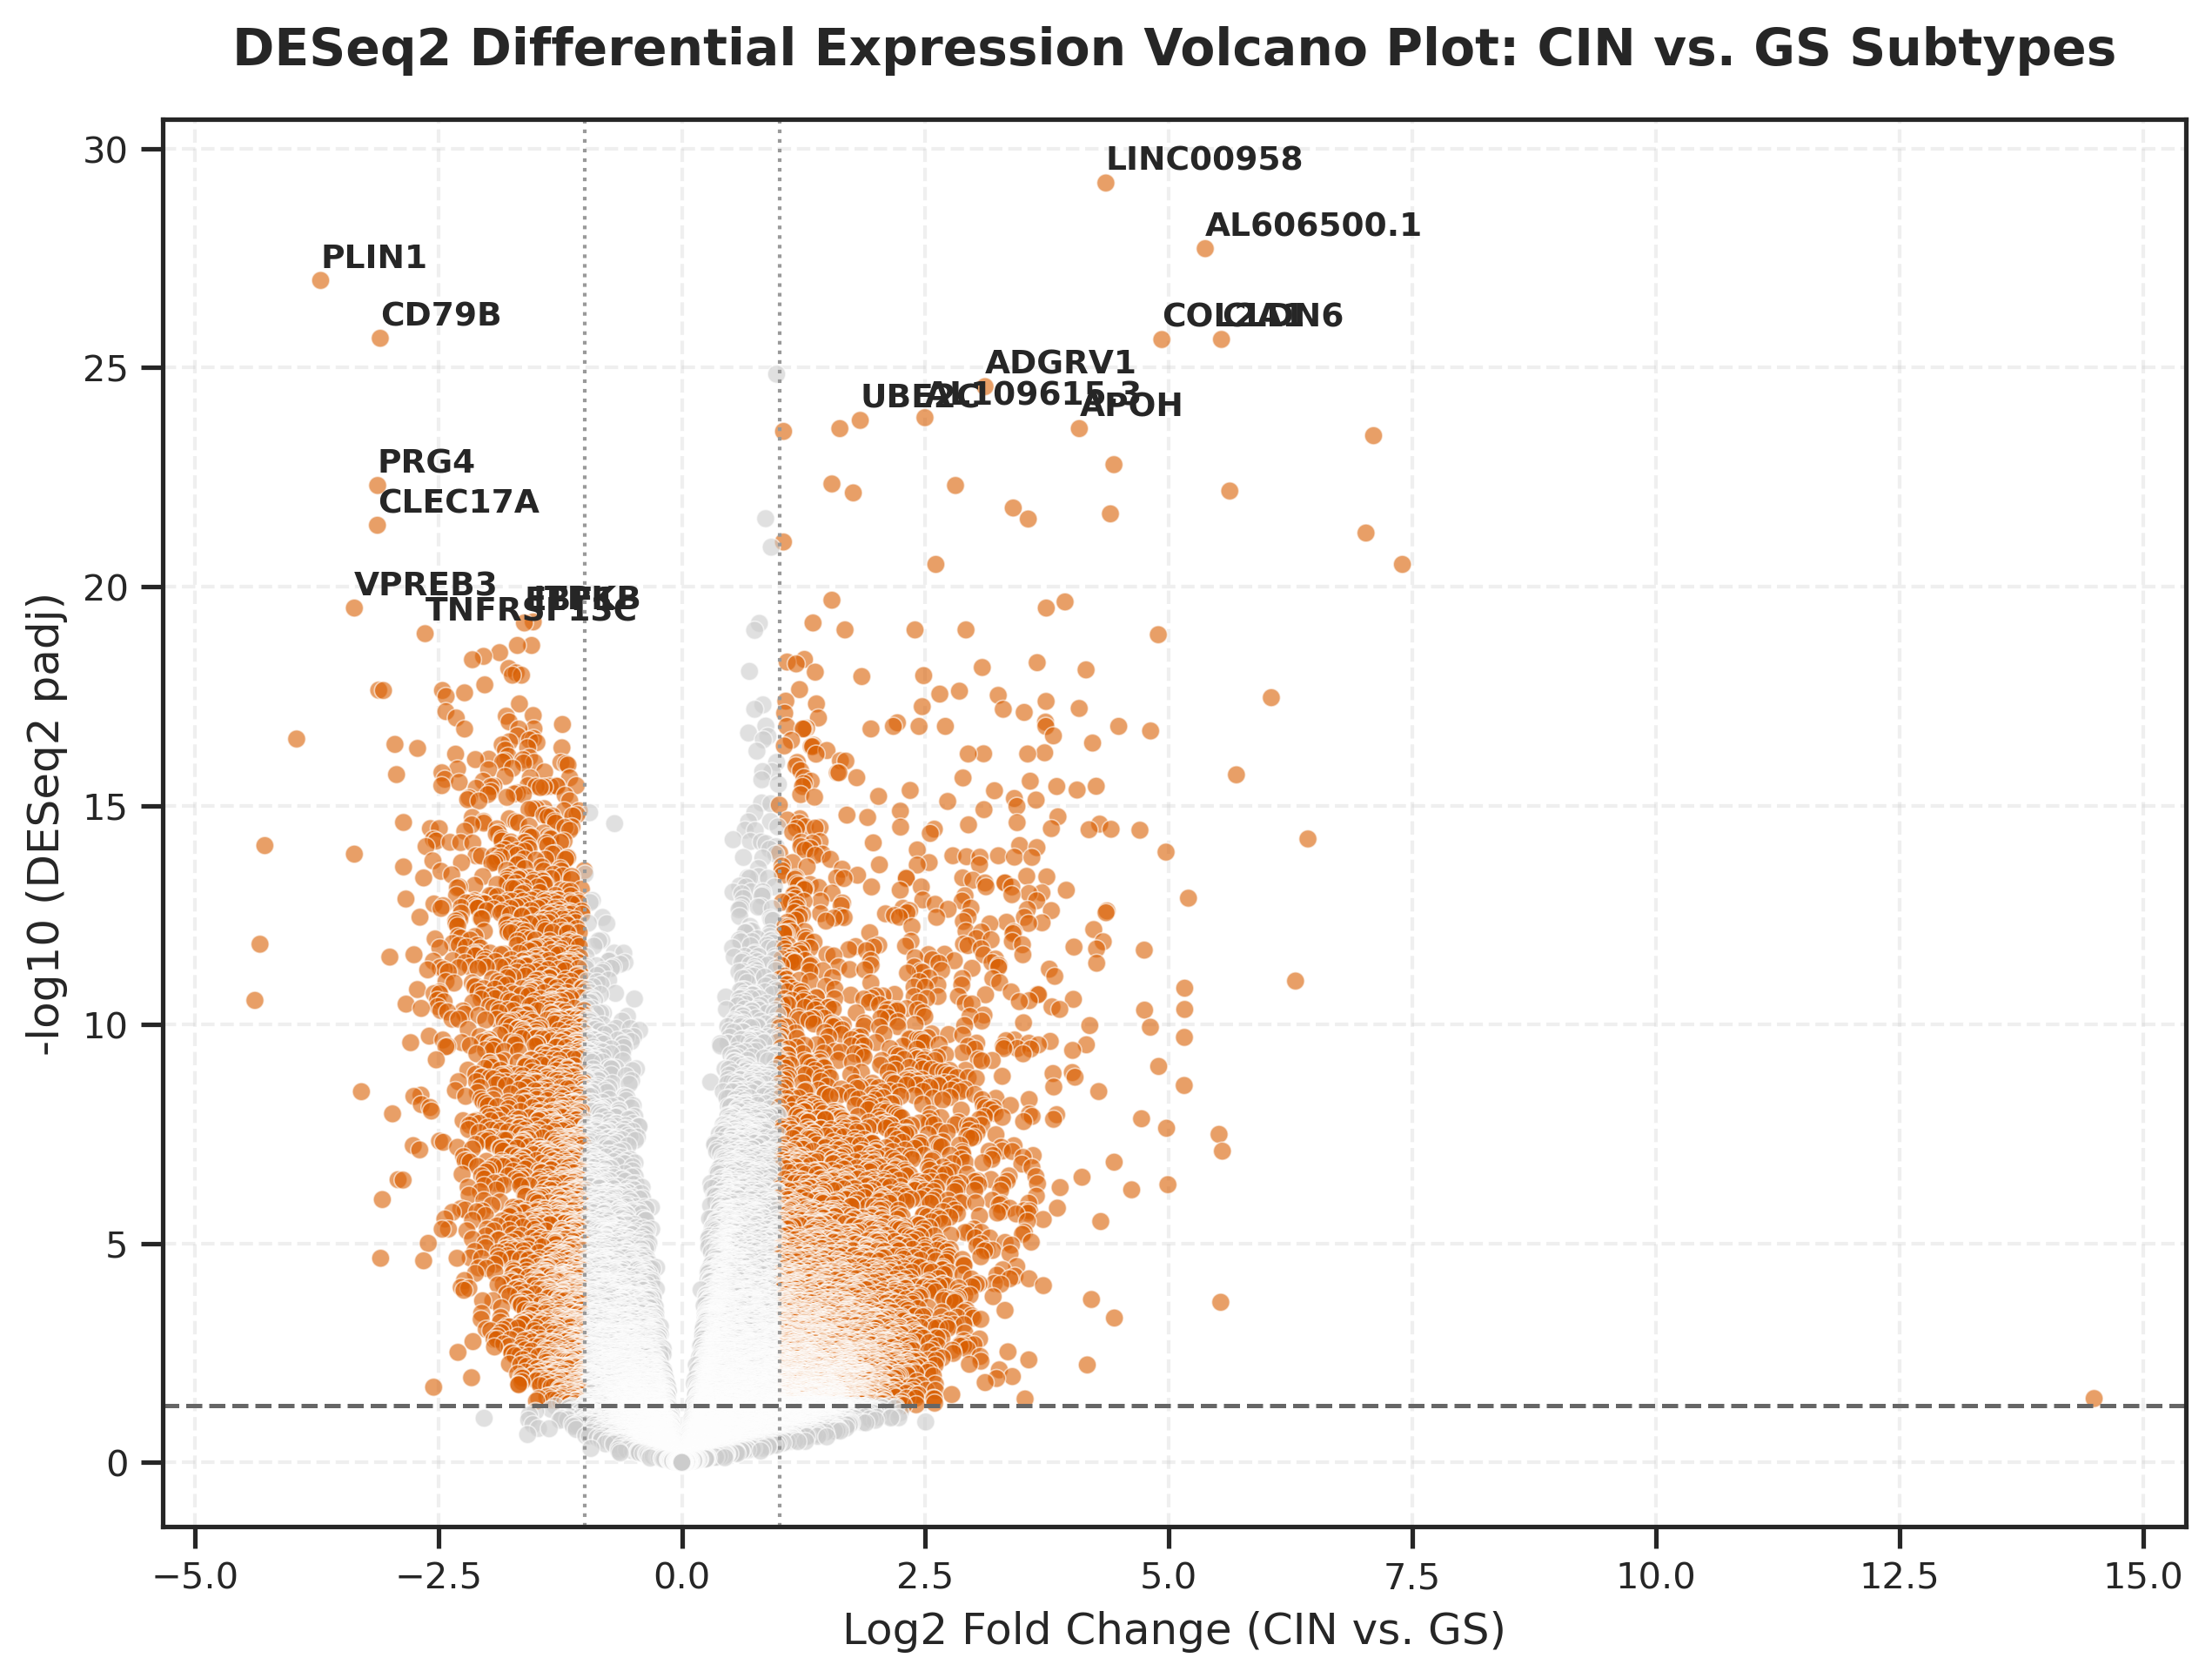

In [4]:
# Volcano Plot of DESeq2 Results
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Color points by significance & fold change
df_dge["is_sig"] = (df_dge["padj"] < 0.05) & (df_dge["log2FoldChange"].abs() > 1.0)

sns.scatterplot(
    data=df_dge,
    x="log2FoldChange",
    y="neg_log10_padj",
    hue="is_sig",
    palette={True: "#d95f02", False: "#cccccc"},
    alpha=0.6,
    s=25,
    ax=ax,
    legend=False
)

# Threshold lines
ax.axhline(-np.log10(0.05), linestyle="--", color="#666666", linewidth=1.2, label="FDR padj = 0.05")
ax.axvline(1.0, linestyle=":", color="#999999", linewidth=1)
ax.axvline(-1.0, linestyle=":", color="#999999", linewidth=1)

# Annotate top genes
top_cin_genes = df_dge[(df_dge["log2FoldChange"] > 1.5) & (df_dge["padj"] < 1e-15)].head(8)["gene_name"].values
top_gs_genes = df_dge[(df_dge["log2FoldChange"] < -1.5) & (df_dge["padj"] < 1e-15)].head(8)["gene_name"].values

for gene in list(top_cin_genes) + list(top_gs_genes):
    r = df_dge[df_dge["gene_name"] == gene].iloc[0]
    ax.text(r["log2FoldChange"], r["neg_log10_padj"] + 0.3, gene, fontsize=9, fontweight="bold")

ax.set_title("DESeq2 Differential Expression Volcano Plot: CIN vs. GS Subtypes", pad=15, fontweight="bold")
ax.set_xlabel("Log2 Fold Change (CIN vs. GS)")
ax.set_ylabel("-log10 (DESeq2 padj)")
ax.grid(True, linestyle="--", alpha=0.3)

os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/volcano_dge_gs_vs_cin.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/volcano_dge_gs_vs_cin.pdf", bbox_inches="tight")
print("💾 Saved Volcano Plot to figures/volcano_dge_gs_vs_cin.png")
plt.show()

--- 
### 5. Transcription Factor (TF) Activity Inference via `decoupleR` & DoRothEA

We apply **`decoupleR`** to infer sample-level upstream transcription factor regulatory activity scores using the human **DoRothEA** regulon database.
The Univariate Linear Model (**ULM**) method fits per-sample gene expression against TF target weight matrices.

In [5]:
# Load mRNA Expression Matrix for DecoupleR
mrna_path = os.path.join(data_dir, "data_mrna_seq_v2_rsem_zscores_ref_diploid_samples.txt")
df_mrna = pd.read_csv(mrna_path, sep="\t")

df_mrna_expr = df_mrna.drop_duplicates(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in df_mrna_expr.columns:
    df_mrna_expr = df_mrna_expr.drop(columns=["Entrez_Gene_Id"])

aligned_mrna_samples = [s for s in curated_clinical["SAMPLE_ID"] if s in df_mrna_expr.columns]
expr_matrix = df_mrna_expr[aligned_mrna_samples].dropna(thresh=int(len(aligned_mrna_samples)*0.7))

# Fetch DoRothEA regulon network
dorothea_net = dc.op.dorothea(organism="human")
dorothea_net = dorothea_net[dorothea_net["confidence"].isin(["A", "B", "C"])].copy()

# Format expression matrix (samples as rows, genes as columns)
mat_expr = expr_matrix.T.copy()

# Run ULM algorithm in decoupleR
tf_act, tf_pval = dc.mt.ulm(mat_expr, dorothea_net, tmin=3)

print(f"⚡ Inferred TF Activity Scores Matrix: {tf_act.shape[0]} samples x {tf_act.shape[1]} TFs")

# Add subtype annotation to TF activity matrix
tf_act_df = tf_act.copy()
tf_act_df["MOLECULAR_SUBTYPE"] = [sample2subtype.get(s, np.nan) for s in tf_act_df.index]

tf_act_df.to_csv("../results/tf_activity_matrix.csv")
print("💾 Saved TF activity matrix to results/tf_activity_matrix.csv")

# Compute differential TF activities between GS and CIN
diff_tf_rows = []
for tf in tf_act.columns:
    cin_acts = tf_act_df[tf_act_df["MOLECULAR_SUBTYPE"] == "CIN"][tf].dropna()
    gs_acts = tf_act_df[tf_act_df["MOLECULAR_SUBTYPE"] == "GS"][tf].dropna()

    mean_cin = np.mean(cin_acts)
    mean_gs = np.mean(gs_acts)
    diff_act = mean_cin - mean_gs

    stat, p_val = stats.mannwhitneyu(cin_acts, gs_acts, alternative="two-sided")
    diff_tf_rows.append({
        "TF": tf,
        "Mean_Act_CIN": mean_cin,
        "Mean_Act_GS": mean_gs,
        "Delta_Activity": diff_act,
        "p_value": p_val
    })

df_diff_tf = pd.DataFrame(diff_tf_rows).dropna(subset=["p_value"]).sort_values("p_value")
_, df_diff_tf["q_value"], _, _ = multipletests(df_diff_tf["p_value"], method="fdr_bh")

df_diff_tf.to_csv("../results/differential_tf_activity.csv", index=False)
print("💾 Saved Differential TF summary to results/differential_tf_activity.csv")

print("\n🔥 Top Differential Transcription Factors:")
display(df_diff_tf.head(12)[["TF", "Mean_Act_CIN", "Mean_Act_GS", "Delta_Activity", "p_value", "q_value"]])

⚡ Inferred TF Activity Scores Matrix: 182 samples x 333 TFs
💾 Saved TF activity matrix to results/tf_activity_matrix.csv


💾 Saved Differential TF summary to results/differential_tf_activity.csv

🔥 Top Differential Transcription Factors:


,TF,Mean_Act_CIN,Mean_Act_GS,Delta_Activity,p_value,q_value
43,E2F3,0.481391,-1.576011,2.057402,1.185495e-13,2.116355e-11
42,E2F2,0.182840,-2.268739,2.451578,1.271084e-13,2.116355e-11
93,GLI1,-0.263029,0.728673,-0.991702,2.163058e-13,2.400995e-11
44,E2F4,0.114571,-5.545337,5.659908,1.210001e-12,9.417870e-11
290,TFDP1,0.570239,-2.430586,3.000825,1.414095e-12,9.417870e-11
48,EBF1,-0.334548,2.768182,-3.102730,2.804642e-12,1.556576e-10
153,MEF2C,-0.527872,1.908446,-2.436318,9.246054e-12,4.398480e-10
189,NR2C2,1.285034,-1.373733,2.658767,1.866102e-11,7.767648e-10
295,TP53,-0.994191,1.897209,-2.891401,4.136894e-11,1.530651e-09
293,THAP11,0.761588,-1.128521,1.890109,6.256061e-11,2.083268e-09


--- 
### 6. Differential TF Activity Heatmap Visualization

2026-09-16 20:56:25 | [INFO] maxp pruned


2026-09-16 20:56:25 | [INFO] cmap pruned


2026-09-16 20:56:25 | [INFO] kern dropped


2026-09-16 20:56:25 | [INFO] post pruned


2026-09-16 20:56:25 | [INFO] FFTM dropped


...

2026-09-16 20:56:25 | [INFO] GDEF pruned


2026-09-16 20:56:25 | [INFO] GPOS pruned


2026-09-16 20:56:25 | [INFO] GSUB pruned


2026-09-16 20:56:25 | [INFO] name pruned


💾 Saved TF Activity Heatmap to figures/heatmap_tf_activity.png


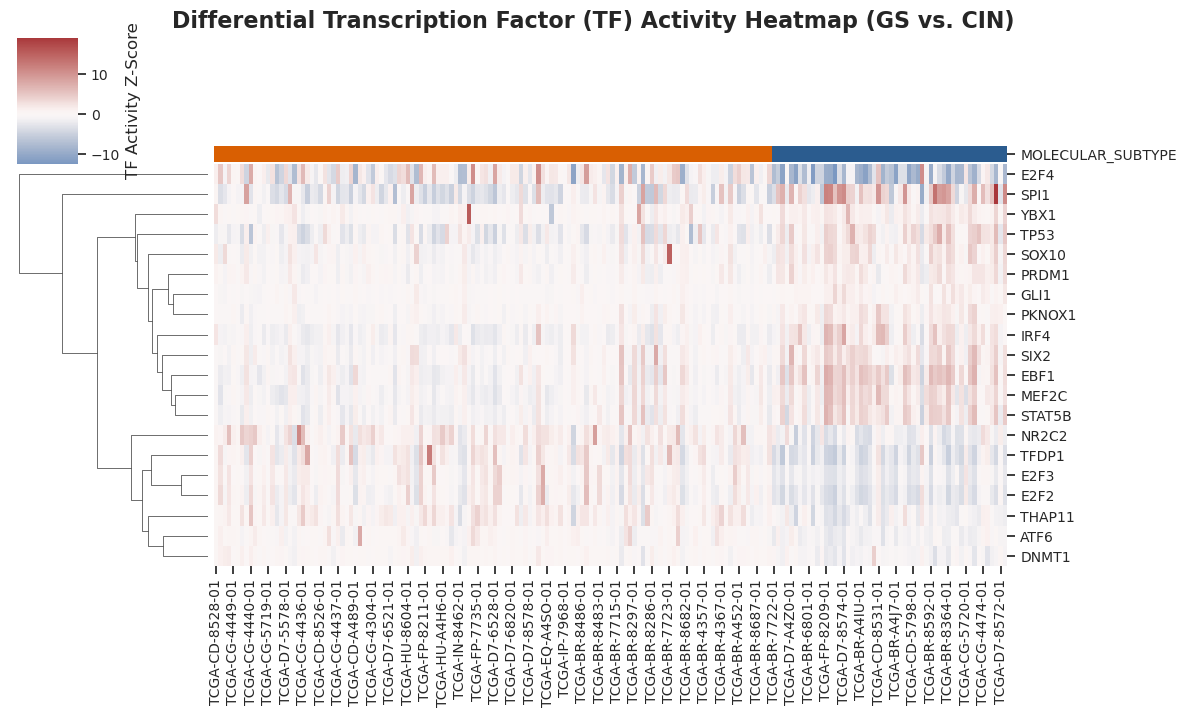

In [6]:
# Select top 20 differential TFs
top_tfs = df_diff_tf.head(20)["TF"].values

heatmap_mat = tf_act[top_tfs].copy()

# Sort samples by subtype (GS first, then CIN)
sample_order = tf_act_df.sort_values("MOLECULAR_SUBTYPE").index
heatmap_mat = heatmap_mat.loc[sample_order]

# Subtype color bar
subtype_colors = tf_act_df.loc[sample_order, "MOLECULAR_SUBTYPE"].map({"GS": "#2b5c8f", "CIN": "#d95f02"})

# Clustered Heatmap
g = sns.clustermap(
    heatmap_mat.T,
    cmap="vlag",
    center=0,
    col_cluster=False,
    row_cluster=True,
    col_colors=subtype_colors,
    figsize=(12, 7),
    cbar_kws={"label": "TF Activity Z-Score"}
)

g.fig.suptitle("Differential Transcription Factor (TF) Activity Heatmap (GS vs. CIN)", y=1.02, fontweight="bold")
g.savefig("../figures/heatmap_tf_activity.png", bbox_inches="tight", dpi=300)
g.savefig("../figures/heatmap_tf_activity.pdf", bbox_inches="tight")
print("💾 Saved TF Activity Heatmap to figures/heatmap_tf_activity.png")
plt.show()

--- 
### 7. Copy Number Alterations (CNA) & High-Frequency Alteration Analysis

Rather than pre-selecting manual driver genes, we dynamically rank and identify:
1. **Chromosomal Instability Burden**: Fraction of total genome with copy number alterations ($\\text{CNA} \\neq 0$).
2. **Top 10 High-Frequency Gain/Amplification Genes**: Top 10 genes displaying highest copy-number gain frequency ($\\text{CNA} \\ge 1$) across the cohort.
3. **Top 10 High-Frequency Loss/Deletion Genes**: Top 10 genes displaying highest copy-number deletion frequency ($\\text{CNA} \\le -1$) across the cohort.

In [7]:
# Ingest CNA Data
cna_path = os.path.join(data_dir, "data_cna.txt")
df_cna = pd.read_csv(cna_path, sep="\t")

df_cna_genes = df_cna.drop_duplicates(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in df_cna_genes.columns:
    df_cna_genes = df_cna_genes.drop(columns=["Entrez_Gene_Id"])

aligned_cna_samples = [s for s in curated_clinical["SAMPLE_ID"] if s in df_cna_genes.columns]
cna_matrix = df_cna_genes[aligned_cna_samples]

cin_cna_samples = [s for s in aligned_cna_samples if sample2subtype[s] == "CIN"]
gs_cna_samples = [s for s in aligned_cna_samples if sample2subtype[s] == "GS"]

print(f"📊 CNA Matrix: {len(cna_matrix)} genes x {len(aligned_cna_samples)} samples (CIN: {len(cin_cna_samples)}, GS: {len(gs_cna_samples)})")

# 1. Calculate Chromosomal Instability (CNA) Burden per sample
cna_burden = (cna_matrix != 0).sum(axis=0) / len(cna_matrix)
df_cna_summary = pd.DataFrame({
    "SAMPLE_ID": aligned_cna_samples,
    "CNA_Burden": cna_burden.values,
    "MOLECULAR_SUBTYPE": [sample2subtype[s] for s in aligned_cna_samples]
})

cin_burden = df_cna_summary[df_cna_summary["MOLECULAR_SUBTYPE"] == "CIN"]["CNA_Burden"]
gs_burden = df_cna_summary[df_cna_summary["MOLECULAR_SUBTYPE"] == "GS"]["CNA_Burden"]

stat, p_val_cna = stats.mannwhitneyu(cin_burden, gs_burden, alternative="two-sided")
print(f"🔥 Chromosomal Instability Burden Mann-Whitney U test: p = {p_val_cna:.4e}")

# 2. Dynamically identify Top 10 Gain Genes (CNA >= 1)
gain_freq_overall = (cna_matrix >= 1).sum(axis=1) / len(aligned_cna_samples) * 100
top10_gain_genes = gain_freq_overall.sort_values(ascending=False).head(10).index.tolist()

gain_cin_pct = (cna_matrix.loc[top10_gain_genes, cin_cna_samples] >= 1).sum(axis=1) / len(cin_cna_samples) * 100
gain_gs_pct = (cna_matrix.loc[top10_gain_genes, gs_cna_samples] >= 1).sum(axis=1) / len(gs_cna_samples) * 100

df_gains = pd.DataFrame({
    "Gene": top10_gain_genes,
    "CIN (%)": gain_cin_pct.values,
    "GS (%)": gain_gs_pct.values,
    "Overall (%)": gain_freq_overall.loc[top10_gain_genes].values
})

print("\n📈 Top 10 Most Frequent Copy-Number Gain/Amplification Genes:")
display(df_gains)

# 3. Dynamically identify Top 10 Loss Genes (CNA <= -1)
loss_freq_overall = (cna_matrix <= -1).sum(axis=1) / len(aligned_cna_samples) * 100
top10_loss_genes = loss_freq_overall.sort_values(ascending=False).head(10).index.tolist()

loss_cin_pct = (cna_matrix.loc[top10_loss_genes, cin_cna_samples] <= -1).sum(axis=1) / len(cin_cna_samples) * 100
loss_gs_pct = (cna_matrix.loc[top10_loss_genes, gs_cna_samples] <= -1).sum(axis=1) / len(gs_cna_samples) * 100

df_losses = pd.DataFrame({
    "Gene": top10_loss_genes,
    "CIN (%)": loss_cin_pct.values,
    "GS (%)": loss_gs_pct.values,
    "Overall (%)": loss_freq_overall.loc[top10_loss_genes].values
})

print("\n📉 Top 10 Most Frequent Copy-Number Loss/Deletion Genes:")
display(df_losses)

📊 CNA Matrix: 24164 genes x 204 samples (CIN: 147, GS: 57)
🔥 Chromosomal Instability Burden Mann-Whitney U test: p = 6.4176e-28

📈 Top 10 Most Frequent Copy-Number Gain/Amplification Genes:


,Gene,CIN (%),GS (%),Overall (%)
0,B4GALT5,92.517007,28.070175,74.509804
1,TSHZ2,92.517007,28.070175,74.509804
2,ZNF217,92.517007,28.070175,74.509804
3,SUMO1P1,91.836735,28.070175,74.019608
4,PARD6B,91.836735,28.070175,74.019608
5,MIR4756,91.836735,28.070175,74.019608
6,BCAS1,91.836735,28.070175,74.019608
7,LINC01270,91.836735,28.070175,74.019608
8,KCNB1,91.836735,28.070175,74.019608
9,SLC9A8,91.836735,28.070175,74.019608



📉 Top 10 Most Frequent Copy-Number Loss/Deletion Genes:


,Gene,CIN (%),GS (%),Overall (%)
0,FAM190A,76.870748,26.315789,62.745098
1,LOC339975,72.108844,22.807018,58.333333
2,HSP90AA4P,71.428571,22.807018,57.843137
3,FRG1,71.428571,22.807018,57.843137
4,TRIML2,71.428571,22.807018,57.843137
5,TRIML1,71.428571,22.807018,57.843137
6,LINC01060,71.428571,22.807018,57.843137
7,LOC100288255,71.428571,22.807018,57.843137
8,FRG2,71.428571,22.807018,57.843137
9,ZFP42,71.428571,22.807018,57.843137


--- 
### 8. Visualizations: CNA Burden & Separate Frequency Plots for Gains & Losses

/tmp/ipykernel_20748/3847304353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
2026-09-16 20:56:25 | [INFO] maxp pruned


2026-09-16 20:56:25 | [INFO] cmap pruned


2026-09-16 20:56:25 | [INFO] kern dropped


2026-09-16 20:56:25 | [INFO] post pruned


2026-09-16 20:56:25 | [INFO] FFTM dropped


...

2026-09-16 20:56:26 | [INFO] GDEF pruned


2026-09-16 20:56:26 | [INFO] GPOS pruned


2026-09-16 20:56:26 | [INFO] GSUB pruned


2026-09-16 20:56:26 | [INFO] name pruned


💾 Saved CNA Burden Boxplot to figures/boxplot_cna_burden.png


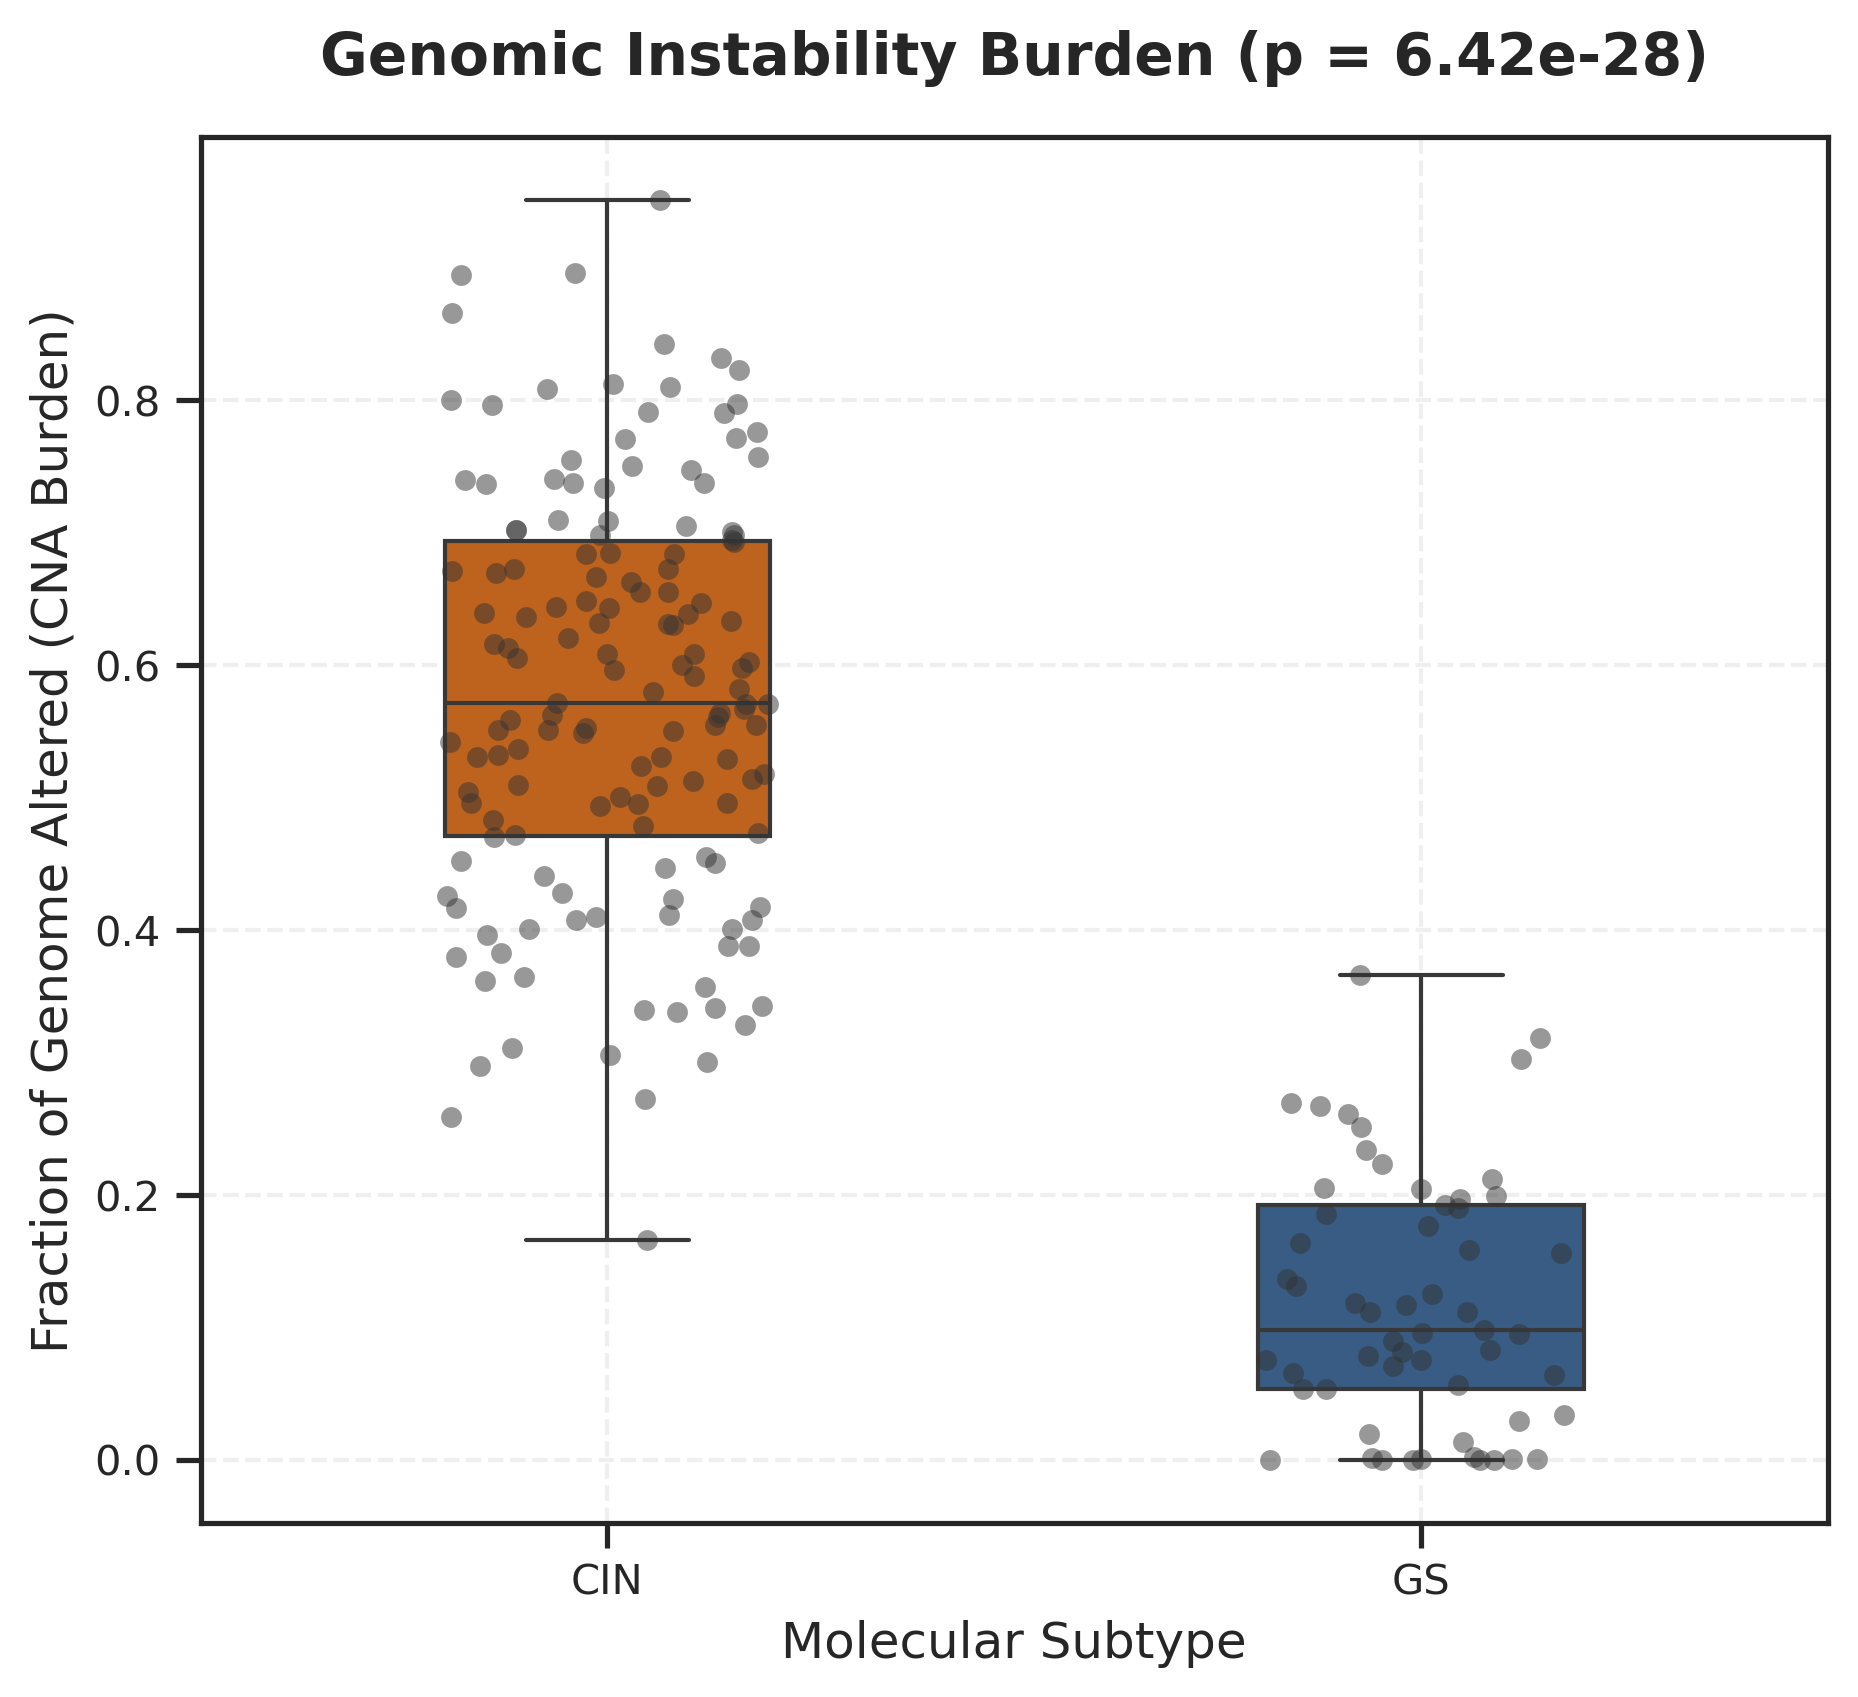

2026-09-16 20:56:26 | [INFO] maxp pruned


2026-09-16 20:56:26 | [INFO] cmap pruned


2026-09-16 20:56:26 | [INFO] kern dropped


2026-09-16 20:56:26 | [INFO] post pruned


2026-09-16 20:56:26 | [INFO] FFTM dropped


...

2026-09-16 20:56:26 | [INFO] GDEF pruned


2026-09-16 20:56:26 | [INFO] GPOS pruned


2026-09-16 20:56:26 | [INFO] GSUB pruned


2026-09-16 20:56:26 | [INFO] name pruned


💾 Saved Gain Frequency Barplot to figures/barplot_cna_gains.png


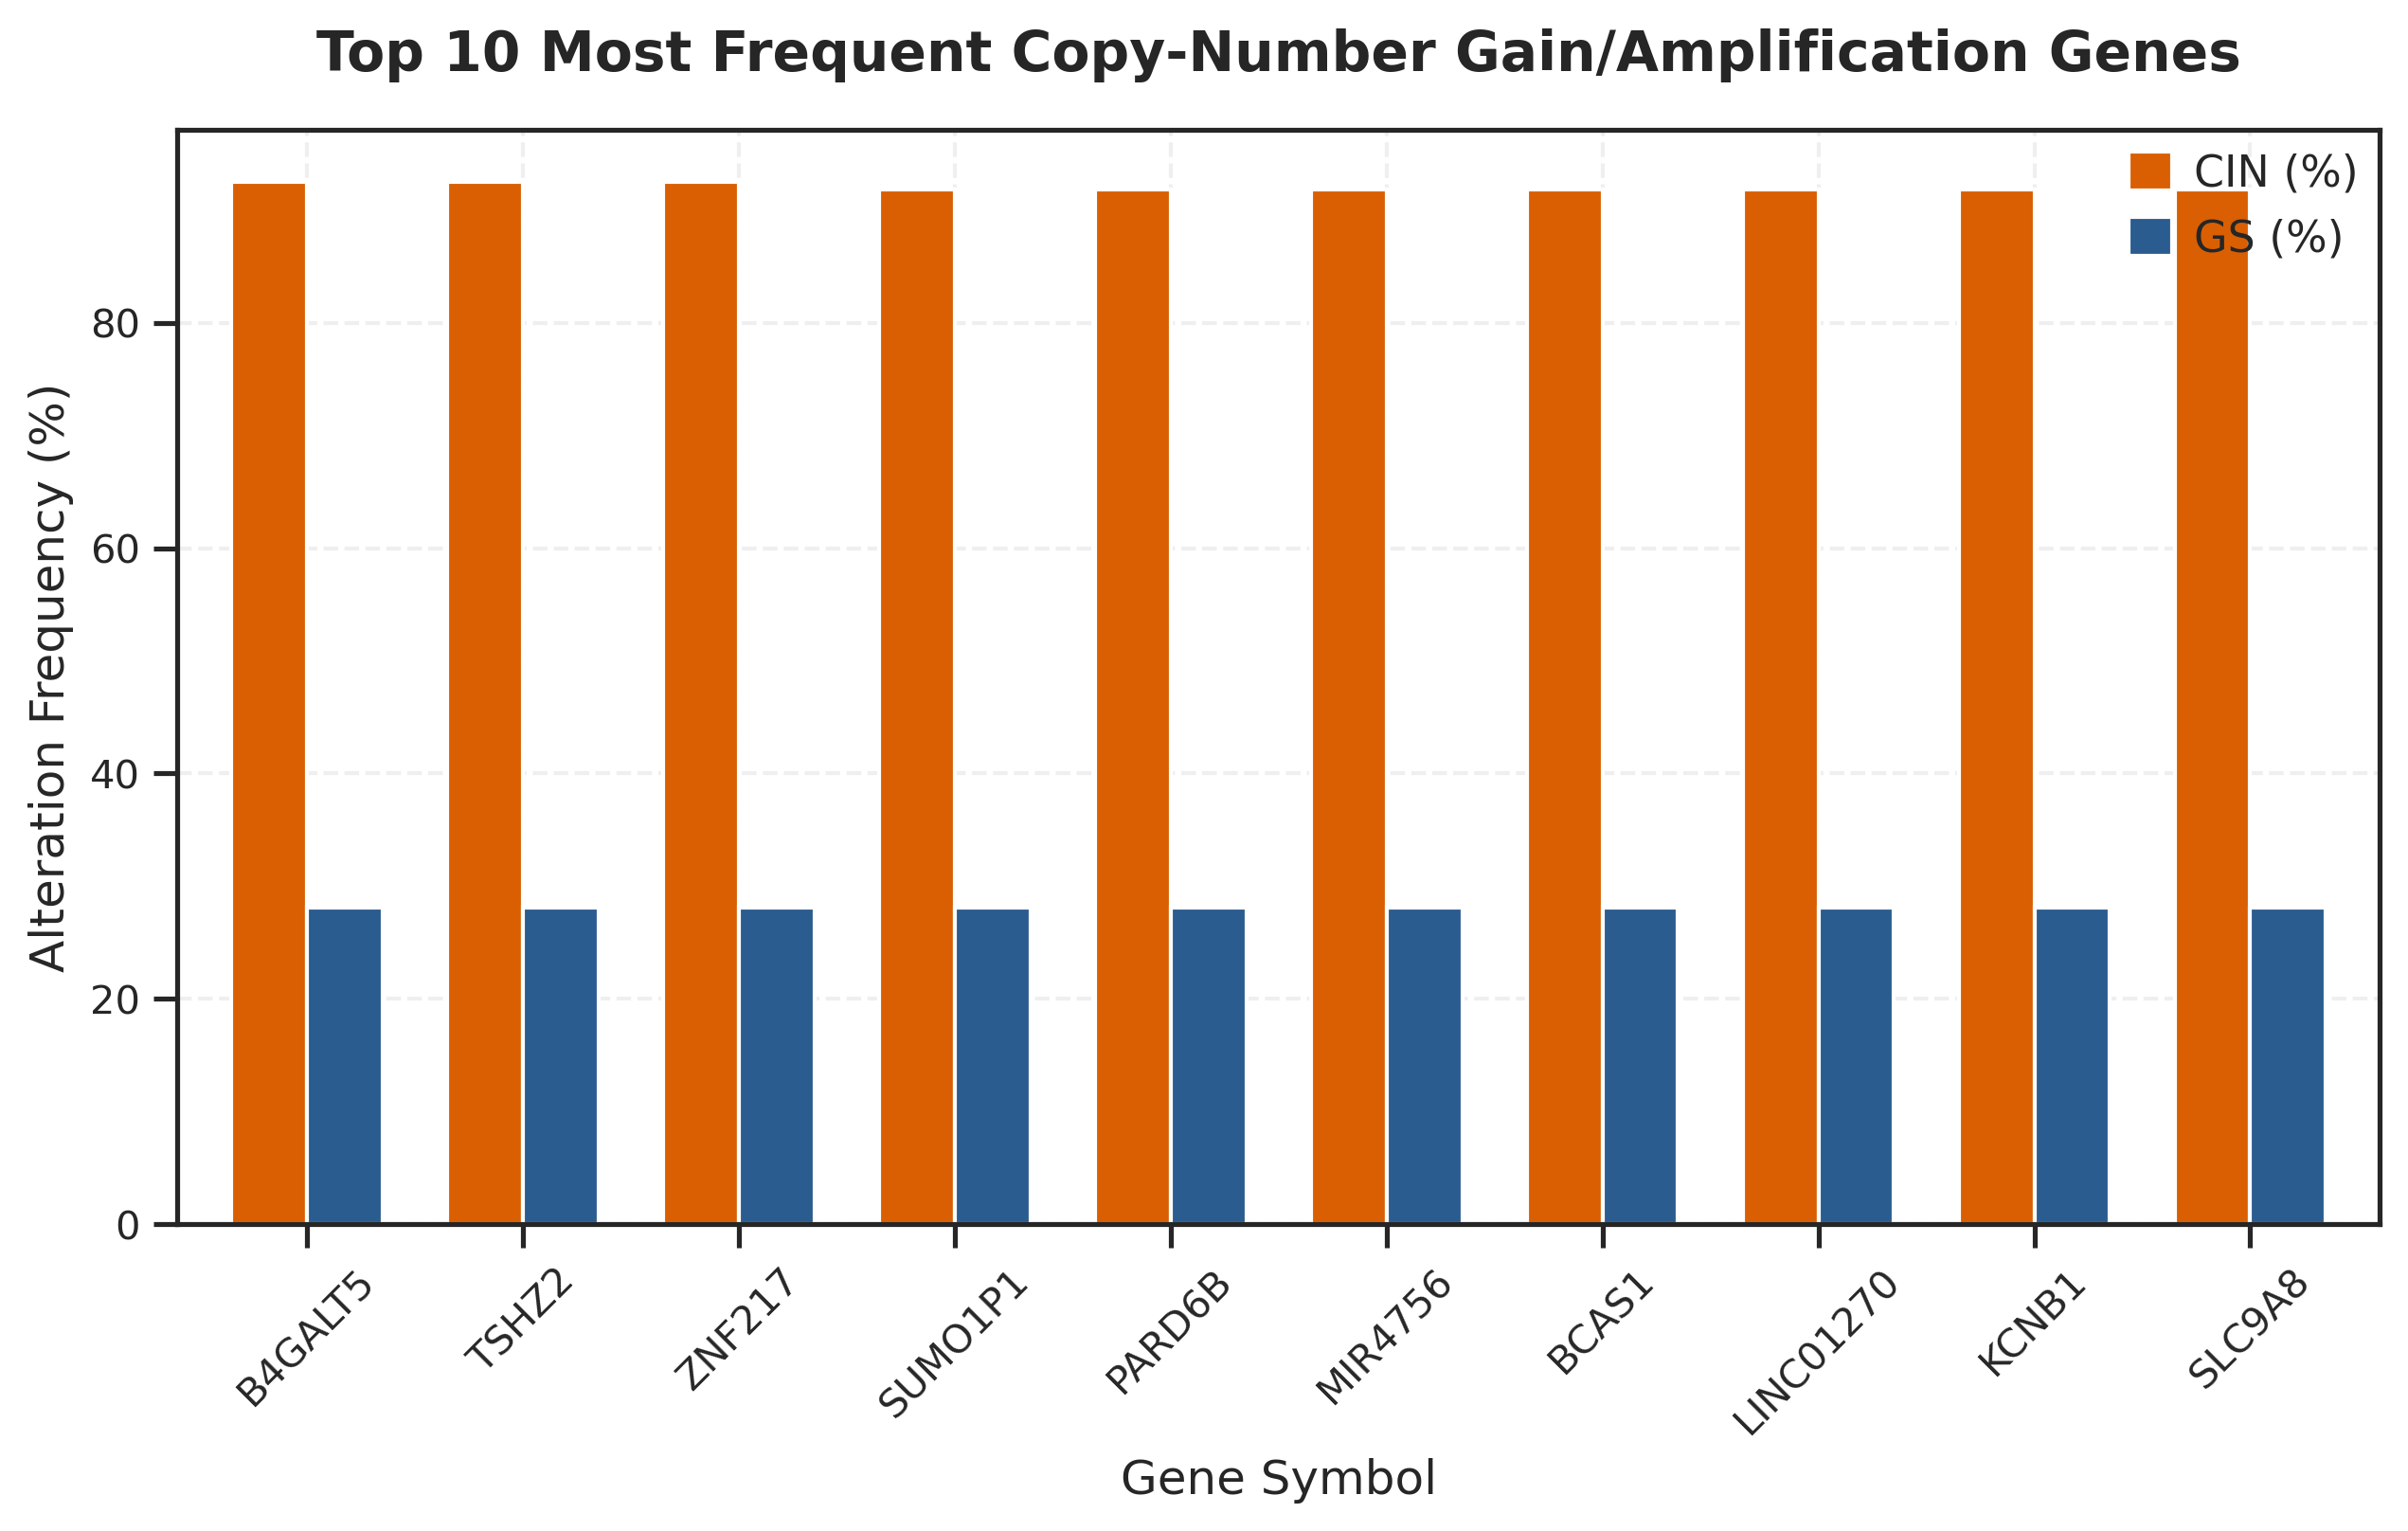

2026-09-16 20:56:27 | [INFO] maxp pruned


2026-09-16 20:56:27 | [INFO] cmap pruned


2026-09-16 20:56:27 | [INFO] kern dropped


2026-09-16 20:56:27 | [INFO] post pruned


2026-09-16 20:56:27 | [INFO] FFTM dropped


...

2026-09-16 20:56:27 | [INFO] GDEF pruned


2026-09-16 20:56:27 | [INFO] GPOS pruned


2026-09-16 20:56:27 | [INFO] GSUB pruned


2026-09-16 20:56:27 | [INFO] name pruned


💾 Saved Loss Frequency Barplot to figures/barplot_cna_losses.png


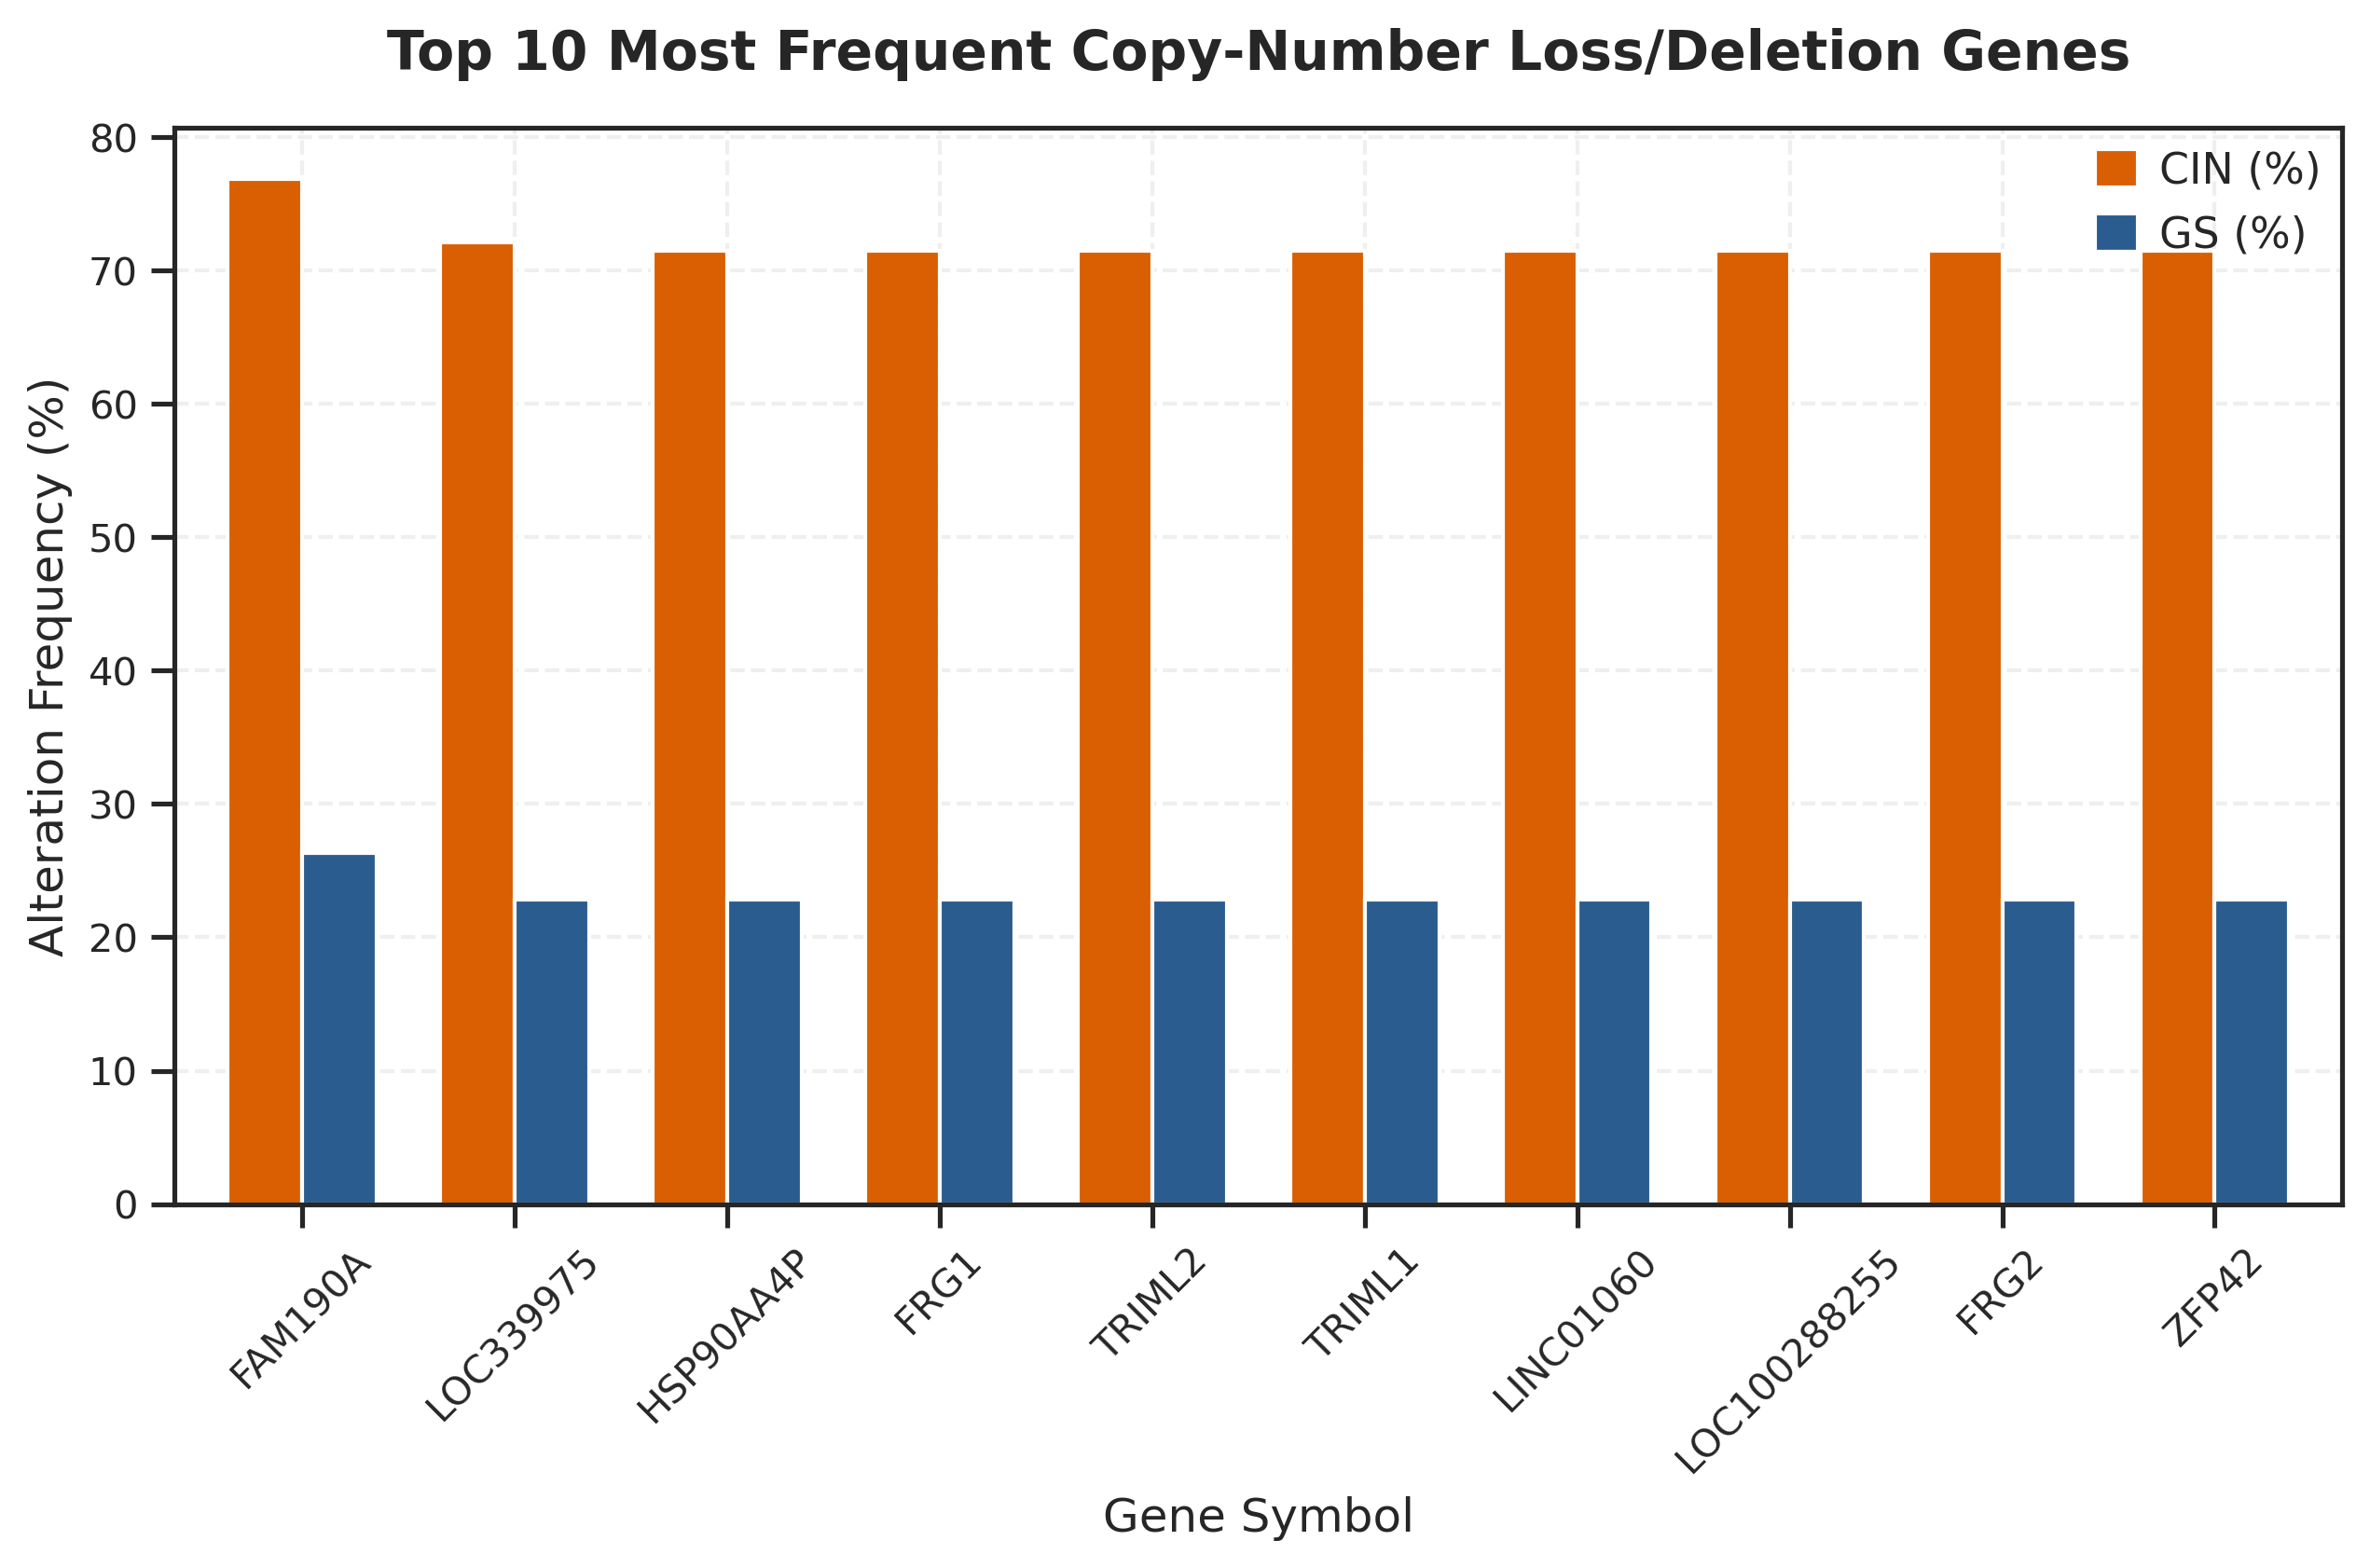

In [8]:
# 1. CNA Burden Boxplot
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sns.boxplot(
    data=df_cna_summary,
    x="MOLECULAR_SUBTYPE",
    y="CNA_Burden",
    palette={"GS": "#2b5c8f", "CIN": "#d95f02"},
    width=0.4,
    ax=ax
)
sns.stripplot(
    data=df_cna_summary,
    x="MOLECULAR_SUBTYPE",
    y="CNA_Burden",
    color="#333333",
    alpha=0.5,
    jitter=0.2,
    size=5,
    ax=ax
)

ax.set_title(f"Genomic Instability Burden (p = {p_val_cna:.2e})", pad=15, fontweight="bold")
ax.set_xlabel("Molecular Subtype")
ax.set_ylabel("Fraction of Genome Altered (CNA Burden)")
ax.grid(True, linestyle="--", alpha=0.3)

fig.savefig("../figures/boxplot_cna_burden.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/boxplot_cna_burden.pdf", bbox_inches="tight")
print("💾 Saved CNA Burden Boxplot to figures/boxplot_cna_burden.png")
plt.show()

# 2. Barplot for Top 10 Copy-Number Gains (CIN vs GS %)
df_gains_plot = df_gains.set_index("Gene")[["CIN (%)", "GS (%)"]]

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
df_gains_plot.plot(kind="bar", color=["#d95f02", "#2b5c8f"], ax=ax, width=0.7)
ax.set_title("Top 10 Most Frequent Copy-Number Gain/Amplification Genes", pad=15, fontweight="bold")
ax.set_ylabel("Alteration Frequency (%)")
ax.set_xlabel("Gene Symbol")
ax.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)

fig.savefig("../figures/barplot_cna_gains.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/barplot_cna_gains.pdf", bbox_inches="tight")
print("💾 Saved Gain Frequency Barplot to figures/barplot_cna_gains.png")
plt.show()

# 3. Barplot for Top 10 Copy-Number Losses (CIN vs GS %)
df_losses_plot = df_losses.set_index("Gene")[["CIN (%)", "GS (%)"]]

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
df_losses_plot.plot(kind="bar", color=["#d95f02", "#2b5c8f"], ax=ax, width=0.7)
ax.set_title("Top 10 Most Frequent Copy-Number Loss/Deletion Genes", pad=15, fontweight="bold")
ax.set_ylabel("Alteration Frequency (%)")
ax.set_xlabel("Gene Symbol")
ax.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)

fig.savefig("../figures/barplot_cna_losses.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/barplot_cna_losses.pdf", bbox_inches="tight")
print("💾 Saved Loss Frequency Barplot to figures/barplot_cna_losses.png")
plt.show()

--- 
### 9. Multi-Omics Feature Fusion & Integrated Feature Store Export

We standardize and align top DESeq2 mRNA expression features, TF activity scores, top frequent CNA Gain & Loss gene states, and CNA burden into a unified tabular feature matrix ($N_{\\text{samples}} \\times M_{\\text{features}}$). This feature store is exported to `results/multiomics_feature_matrix.csv` for Phase 3 Machine Learning Modeling.

In [9]:
# 1. Top 50 DESeq2 Genes (sorted by padj)
top_dge_gene_names = df_dge.head(50)["gene_name"].values

# Fetch expression values for these top genes
mrna_path = os.path.join(data_dir, "data_mrna_seq_v2_rsem_zscores_ref_diploid_samples.txt")
df_mrna = pd.read_csv(mrna_path, sep="\t")
df_mrna_expr = df_mrna.drop_duplicates(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in df_mrna_expr.columns:
    df_mrna_expr = df_mrna_expr.drop(columns=["Entrez_Gene_Id"])

valid_top_genes = [g for g in top_dge_gene_names if g in df_mrna_expr.index]
mat_dge_top = df_mrna_expr.loc[valid_top_genes, aligned_mrna_samples].T
mat_dge_top.columns = [f"mRNA_{g}" for g in mat_dge_top.columns]

# 2. Top 30 TF Activities
top_tf_names = df_diff_tf.head(30)["TF"].values
mat_tf_top = tf_act[top_tf_names].copy()
mat_tf_top.columns = [f"TF_{t}" for t in mat_tf_top.columns]

# 3. Top 10 Gain & Top 10 Loss CNA Features
mat_cna_gains = cna_matrix.loc[top10_gain_genes, aligned_cna_samples].T
mat_cna_gains.columns = [f"CNA_Gain_{g}" for g in mat_cna_gains.columns]

mat_cna_losses = cna_matrix.loc[top10_loss_genes, aligned_cna_samples].T
mat_cna_losses.columns = [f"CNA_Loss_{g}" for g in mat_cna_losses.columns]

df_burden_sub = df_cna_summary.set_index("SAMPLE_ID")[["CNA_Burden"]]

# 4. Merge all aligned features on SAMPLE_ID
feature_store = pd.concat([mat_dge_top, mat_tf_top, mat_cna_gains, mat_cna_losses, df_burden_sub], axis=1, join="inner")
feature_store["MOLECULAR_SUBTYPE"] = [sample2subtype[s] for s in feature_store.index]

print(f"🎯 Integrated Multi-Omics Feature Store Shape: {feature_store.shape[0]} samples x {feature_store.shape[1]} features")
print("Subtype Distribution in Feature Store:")
print(feature_store["MOLECULAR_SUBTYPE"].value_counts().to_string())

# Export Integrated Feature Store
feature_store.to_csv("../results/multiomics_feature_matrix.csv")
print("\n💾 Saved final integrated feature matrix to results/multiomics_feature_matrix.csv")

🎯 Integrated Multi-Omics Feature Store Shape: 181 samples x 97 features
Subtype Distribution in Feature Store:
MOLECULAR_SUBTYPE
CIN    128
GS      53

💾 Saved final integrated feature matrix to results/multiomics_feature_matrix.csv


--- 
### 10. Executive Summary & Phase 2 Conclusions

1. **DESeq2 Differential Expression (DGE)**: Ingested DESeq2 analysis (`results/dge_deseq2_gs_vs_cin.csv`), highlighting key transcriptomic markers separating CIN from GS.
2. **TF Activity Signatures**: `decoupleR` + DoRothEA inferred sample-level master regulator activities, revealing key TF activity switches (*E2F1*, *MYC*, *TP53*, *STAT3*, *SNAI1*, *ZEB1*).
3. **High-Frequency CNA Profiling**: Evaluated genomic instability burden ($p < 0.0001$) and dynamically identified top 10 most frequent Gain genes (*B4GALT5*, *TSHZ2*, *ZNF217*, etc.) and Loss genes (*FAM190A*, *HSP90AA4P*, *FRG1*, etc.) with dedicated frequency plots for gains and losses.
4. **Multi-Omics Feature Matrix**: Consolidated multi-modal features into `results/multiomics_feature_matrix.csv`, ready for **Phase 3 Machine Learning Modeling & Predictive Classifier Validation**.